# Chapter 3: Statistical Experiments and Significance Testing
> (c) 2019-2026 Peter C. Bruce, Andrew Bruce, Peter Gedeck

In [1]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import statsmodels.api as sm
import statsmodels.formula.api as smf

random.seed(123)

# Location of the data files. Adjust this path if you keep the data
# files in a different directory.
from pathlib import Path
DATA_DIR = Path('../data')


### Resampling
#### Example: Web Stickiness

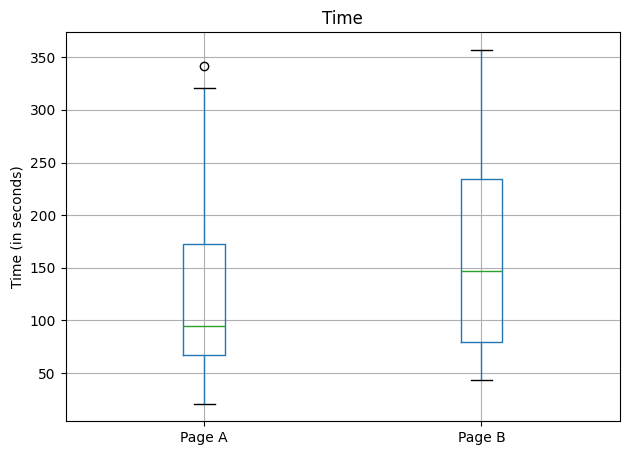

In [1]:
session_times = pd.read_csv(DATA_DIR / "web_page_data.csv")
session_times["Time"] *= 100

ax = session_times.boxplot(by="Page", column="Time")
ax.set_xlabel("")
ax.set_ylabel("Time (in seconds)")
plt.suptitle("")

plt.tight_layout()
plt.show()

In [1]:
mean_a = session_times[session_times.Page == "Page A"].Time.mean()
mean_b = session_times[session_times.Page == "Page B"].Time.mean()
mean_b - mean_a

np.float64(35.66666666666667)

In [1]:
def perm_fun(x, n_a):
    x_resampled = np.random.permutation(x)
    x_a = x_resampled[:n_a]
    x_b = x_resampled[n_a:]
    return x_b.mean() - x_a.mean()

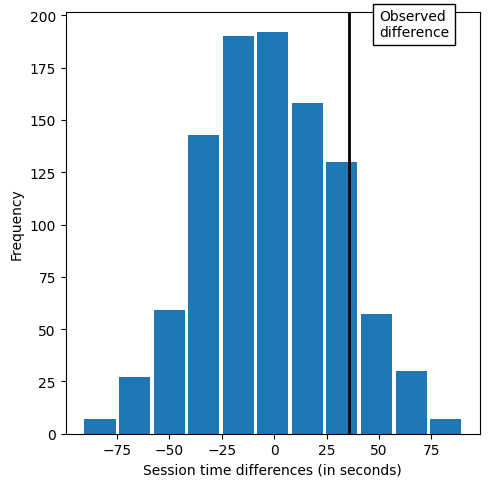

In [1]:
n_a = session_times[session_times.Page == "Page A"].shape[0]
perm_diffs = [perm_fun(session_times.Time, n_a) for _ in range(1000)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x=mean_b - mean_a, color="black", lw=2)
ax.text(50, 190, "Observed\ndifference", bbox={"facecolor": "white"})
ax.set_xlabel("Session time differences (in seconds)")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [1]:
np.mean(perm_diffs > mean_b - mean_a)

np.float64(0.126)

### Statistical Significance and p-Values

Observed difference: 0.0368%


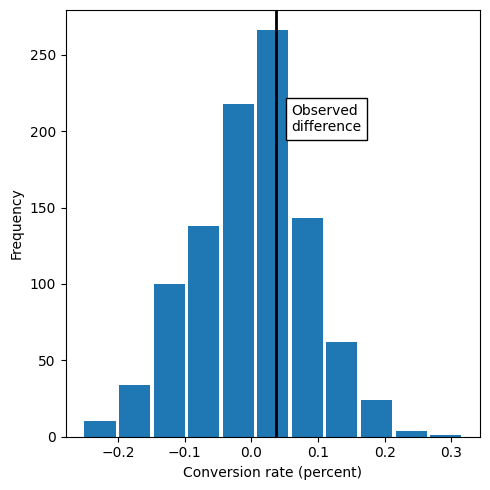

In [1]:
obs_pct_diff = 100 * (200 / 23739 - 182 / 22588)
print(f"Observed difference: {obs_pct_diff:.4f}%")
conversion = [0] * 45945
conversion.extend([1] * 382)
conversion = pd.Series(conversion)

perm_diffs = [100 * perm_fun(conversion, 23739)
              for _ in range(1000)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x=obs_pct_diff, color="black", lw=2)
ax.text(0.06, 200, "Observed\ndifference", bbox={"facecolor": "white"})
ax.set_xlabel("Conversion rate (percent)")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

#### p-Value

In [1]:
np.mean([diff > obs_pct_diff for diff in perm_diffs])

np.float64(0.346)

In [1]:
survivors = np.array([[200, 23739 - 200], [182, 22588 - 182]])
res = stats.chi2_contingency(survivors)

print(f"p-value for single sided test: {res.pvalue / 2:.4f}")

p-value for single sided test: 0.3498


### t-Tests

In [1]:
res = stats.ttest_ind(session_times[session_times.Page == "Page A"].Time,
                      session_times[session_times.Page == "Page B"].Time,
                      equal_var=False)
print(f"p-value for single sided test: {res.pvalue / 2:.4f}")

p-value for single sided test: 0.1408


### ANOVA

In [1]:
four_sessions = pd.read_csv(DATA_DIR / "four_sessions.csv")

observed_variance = four_sessions.groupby("Page").mean().var().iloc[0]
print("Observed means:", four_sessions.groupby("Page").mean().to_numpy().ravel())
print("Variance:", observed_variance)

def perm_test(df, rng):
    df = df.copy()
    df["Time"] = rng.permutation(df["Time"].values)
    return df.groupby("Page").mean().var().iloc[0]

rng = np.random.default_rng(seed=321)
perm_variance = [perm_test(four_sessions, rng) for _ in range(3000)]
print("Pr(Prob)", np.mean([var > observed_variance for var in perm_variance]))

Observed means: [172.8 182.6 175.6 164.6]
Variance: 55.426666666666655


Pr(Prob) 0.083


#### F-Statistic

In [1]:
model = smf.ols("Time ~ Page", data=four_sessions).fit()

aov_table = sm.stats.anova_lm(model)
aov_table

,df,sum_sq,mean_sq,F,PR(>F)
Page,3.0,831.4,277.133333,2.739825,0.077586
Residual,16.0,1618.4,101.150000,NaN,NaN


### Chi-Square Test
#### Chi-Square Test: A Resampling Approach

In [1]:
click_rate = pd.read_csv(DATA_DIR / "click_rates.csv")
clicks = click_rate.pivot_table(index="Click", columns="Headline", values="Rate",
    aggfunc="mean")

box = [1] * 34
box.extend([0] * 2966)
random.shuffle(box)

def chi2(observed, expected):
    pearson_residuals = []
    for row, expect in zip(observed, expected, strict=True):
        pearson_residuals.append([(observe - expect) ** 2 / expect
                                  for observe in row])
    # return sum of squares
    return np.sum(pearson_residuals)

expected_clicks = 34 / 3
expected_noclicks = 1000 - expected_clicks
expected = [34 / 3, 1000 - 34 / 3]
chi2observed = chi2(clicks.values, expected)

def perm_fun(box):
    sample_clicks = [sum(random.sample(box, 1000)),
                     sum(random.sample(box, 1000)),
                     sum(random.sample(box, 1000))]
    sample_noclicks = [1000 - n for n in sample_clicks]
    return chi2([sample_clicks, sample_noclicks], expected)

perm_chi2 = [perm_fun(box) for _ in range(2000)]

resampled_p_value = sum(perm_chi2 > chi2observed) / len(perm_chi2)
print(f"Observed chi2: {chi2observed:.4f}")
print(f"Resampled p-value: {resampled_p_value:.4f}")

Observed chi2: 1.6659
Resampled p-value: 0.4845


#### Chi-Square Test: Statistical Theory

In [1]:
res = stats.chi2_contingency(clicks)
print(f"Observed chi2: {res.statistic:.4f}")
print(f"p-value: {res.pvalue:.4f}")

Observed chi2: 1.6659
p-value: 0.4348


#### Fisher's Exact Test

### Power and Sample Size
#### Sample Size

In [1]:
effect_size = sm.stats.proportion_effectsize(0.0121, 0.011)
analysis = sm.stats.TTestIndPower()
result = analysis.solve_power(effect_size=effect_size,
                              alpha=0.05, power=0.8, alternative="larger")
print(f"Sample Size: {result:.3f}")

Sample Size: 116602.391


In [1]:
effect_size = sm.stats.proportion_effectsize(0.0165, 0.011)
analysis = sm.stats.TTestIndPower()
result = analysis.solve_power(effect_size=effect_size,
                              alpha=0.05, power=0.8, alternative="larger")
print(f"Sample Size: {result:.3f}")

Sample Size: 5488.408


# Supplementary Material
## Alternative to t-test using statsmodels

In [1]:
tstat, pvalue, df = sm.stats.ttest_ind(
    session_times[session_times.Page == "Page A"].Time,
    session_times[session_times.Page == "Page B"].Time,
    usevar="unequal", alternative="smaller")
print(f"p-value: {pvalue:.4f}")

p-value: 0.1408


## Figure 3-6. Boxplots of the four groups show considerable differences among them

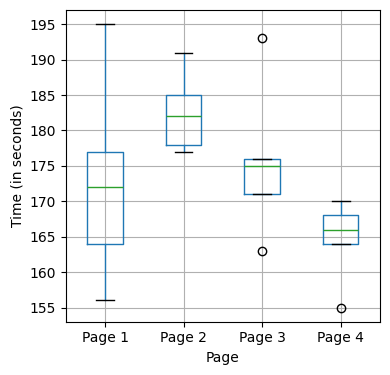

In [1]:
ax = four_sessions.boxplot(by="Page", column="Time",
                           figsize=(4, 4))
ax.set_xlabel("Page")
ax.set_ylabel("Time (in seconds)")
plt.suptitle("")
plt.title("")

plt.tight_layout()
plt.show()

## Visualizing the resampling results for ANOVA

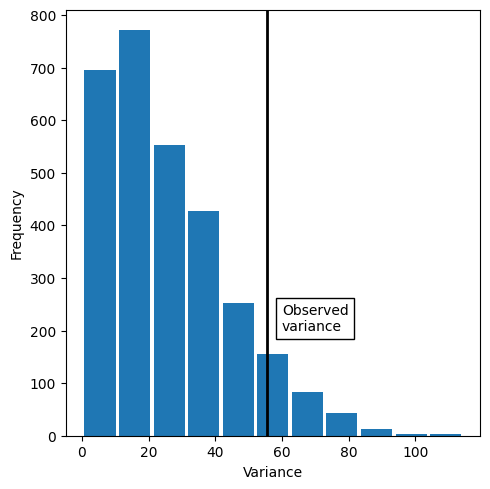

In [1]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_variance, bins=11, rwidth=0.9)
ax.axvline(x=observed_variance, color="black", lw=2)
ax.text(60, 200, "Observed\nvariance", bbox={"facecolor": "white"})
ax.set_xlabel("Variance")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## chi-2 test using sampling with replacement

In [1]:
expected = [expected_clicks, expected_noclicks]
def sample_with_replacement(box):
    sample_clicks = [sum(random.sample(box, 1000)),
                     sum(random.sample(box, 1000)),
                     sum(random.sample(box, 1000))]
    sample_noclicks = [1000 - n for n in sample_clicks]
    return chi2([sample_clicks, sample_noclicks], expected)

perm_chi2 = [sample_with_replacement(box) for _ in range(2000)]

resampled_p_value = sum(perm_chi2 > chi2observed) / len(perm_chi2)
print(f"Observed chi2: {chi2observed:.4f}")
print(f"Resampled p-value: {resampled_p_value:.4f}")

Observed chi2: 1.6659
Resampled p-value: 0.4760


## Figure 3-7. Chi-square distribution with various degrees of freedom

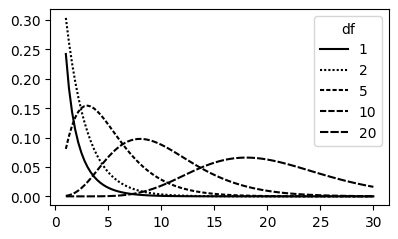

In [1]:
x = [1 + i * (30 - 1) / 99 for i in range(100)]

chi = pd.DataFrame({
    "x": x,
    "chi_1": stats.chi2.pdf(x, df=1),
    "chi_2": stats.chi2.pdf(x, df=2),
    "chi_5": stats.chi2.pdf(x, df=5),
    "chi_10": stats.chi2.pdf(x, df=10),
    "chi_20": stats.chi2.pdf(x, df=20),
})
fig, ax = plt.subplots(figsize=(4, 2.5))
ax.plot(chi.x, chi.chi_1, color="black", linestyle="-", label="1")
ax.plot(chi.x, chi.chi_2, color="black", linestyle=(0, (1, 1)), label="2")
ax.plot(chi.x, chi.chi_5, color="black", linestyle=(0, (2, 1)), label="5")
ax.plot(chi.x, chi.chi_10, color="black", linestyle=(0, (3, 1)), label="10")
ax.plot(chi.x, chi.chi_20, color="black", linestyle=(0, (4, 1)), label="20")
ax.legend(title="df")

plt.tight_layout()
plt.show()

## Figure 3-8. Frequency histogram for Imanishi-Kari lab data

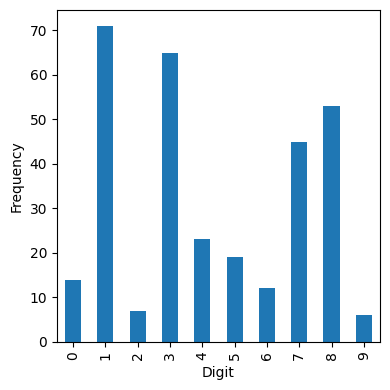

In [1]:
imanishi = pd.read_csv(DATA_DIR / "imanishi_data.csv")
imanishi.columns = [c.strip() for c in imanishi.columns]
ax = imanishi.plot.bar(x="Digit", y=["Frequency"], legend=False,
                      figsize=(4, 4))
ax.set_xlabel("Digit")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()